In [1]:
# ============================================
# Notebook 06
# Vendor Tracker Dashboard
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
project_folder = "Executive_Assistant_Business_Dashboard"

data_folder = os.path.join(project_folder, "data")
reports_folder = os.path.join(project_folder, "reports")
charts_folder = os.path.join(project_folder, "charts")

os.makedirs(reports_folder, exist_ok=True)
os.makedirs(charts_folder, exist_ok=True)

In [3]:
vendor_file = os.path.join(data_folder, "vendors.xlsx")

vendor_df = pd.read_excel(vendor_file)

vendor_df.head()

,Vendor_ID,Vendor_Name,Category,Contact_Person,Email,Phone,Payment_Status,Contract_Value,Last_Meeting
0,VEN001,"Bahl, Vohra and Ravi",Software,Tanvi Peri,xitiroy@example.net,4610431388,Paid,313862.95,2026-03-31 20:35:44.865
1,VEN002,"Rajagopalan, Bawa and Pradhan",Consulting,Hemal Bala,kmannan@example.com,5280218952,Paid,369446.57,2026-04-11 20:35:44.866
2,VEN003,Ganesh Group,IT Services,Xavier Lanka,oscarbaria@example.com,916705583101,Pending,401461.76,2026-04-27 20:35:44.866
3,VEN004,"Rastogi, Bhatti and Dhillon",Logistics,Parth Raval,prabhumahika@example.net,4327233016,Paid,313451.42,2026-04-21 20:35:44.866
4,VEN005,Narula Inc,IT Services,Yashodhara Merchant,ijani@example.com,915583084483,Pending,458950.28,2026-06-09 20:35:44.866


In [4]:
vendor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Vendor_ID       80 non-null     object        
 1   Vendor_Name     80 non-null     object        
 2   Category        80 non-null     object        
 3   Contact_Person  80 non-null     object        
 4   Email           80 non-null     object        
 5   Phone           80 non-null     int64         
 6   Payment_Status  80 non-null     object        
 7   Contract_Value  80 non-null     float64       
 8   Last_Meeting    80 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 5.8+ KB


In [5]:
vendor_df.isnull().sum()

Vendor_ID         0
Vendor_Name       0
Category          0
Contact_Person    0
Email             0
Phone             0
Payment_Status    0
Contract_Value    0
Last_Meeting      0
dtype: int64

In [6]:
vendor_df["Last_Meeting"] = pd.to_datetime(vendor_df["Last_Meeting"])

In [7]:
total_vendors = len(vendor_df)

paid = (vendor_df["Payment_Status"] == "Paid").sum()

pending = (vendor_df["Payment_Status"] == "Pending").sum()

partial = (vendor_df["Payment_Status"] == "Partially Paid").sum()

total_contract = round(vendor_df["Contract_Value"].sum(),2)

average_contract = round(vendor_df["Contract_Value"].mean(),2)

In [8]:
print("="*60)

print("VENDOR DASHBOARD")

print("="*60)

print(f"Total Vendors         : {total_vendors}")

print(f"Paid Vendors          : {paid}")

print(f"Pending Payments      : {pending}")

print(f"Partially Paid        : {partial}")

print(f"Total Contract Value  : ₹{total_contract:,.2f}")

print(f"Average Contract      : ₹{average_contract:,.2f}")

VENDOR DASHBOARD
Total Vendors         : 80
Paid Vendors          : 27
Pending Payments      : 29
Partially Paid        : 24
Total Contract Value  : ₹22,039,477.53
Average Contract      : ₹275,493.47


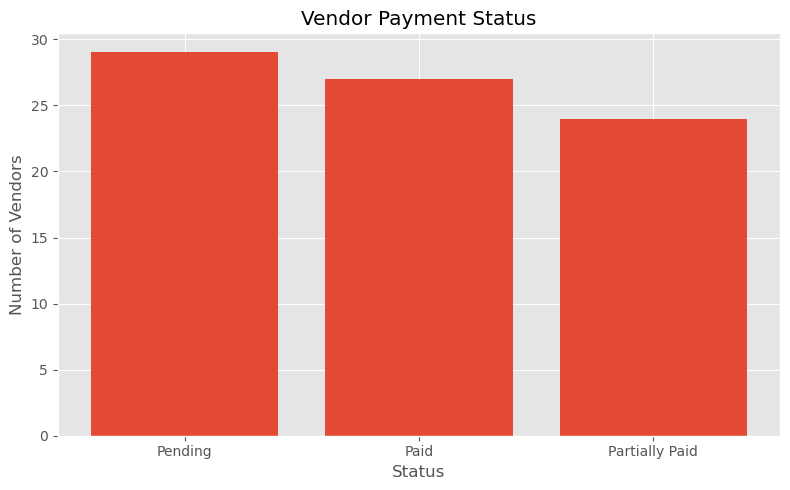

In [9]:
payment = vendor_df["Payment_Status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(payment.index, payment.values)

plt.title("Vendor Payment Status")

plt.xlabel("Status")

plt.ylabel("Number of Vendors")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Vendor_Payment_Status.png"))

plt.show()

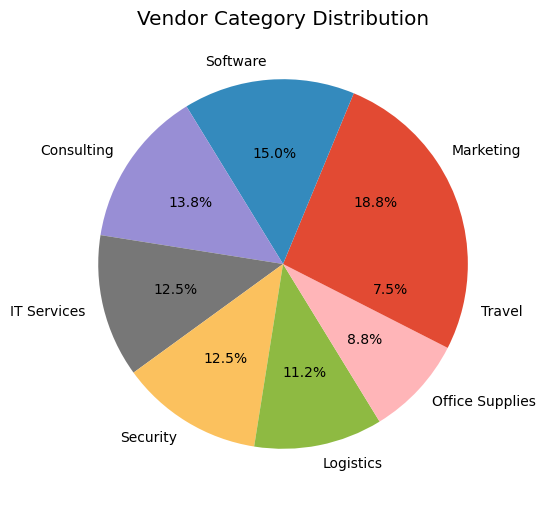

In [10]:
category = vendor_df["Category"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%"
)

plt.title("Vendor Category Distribution")

plt.savefig(os.path.join(charts_folder,"Vendor_Category.png"))

plt.show()

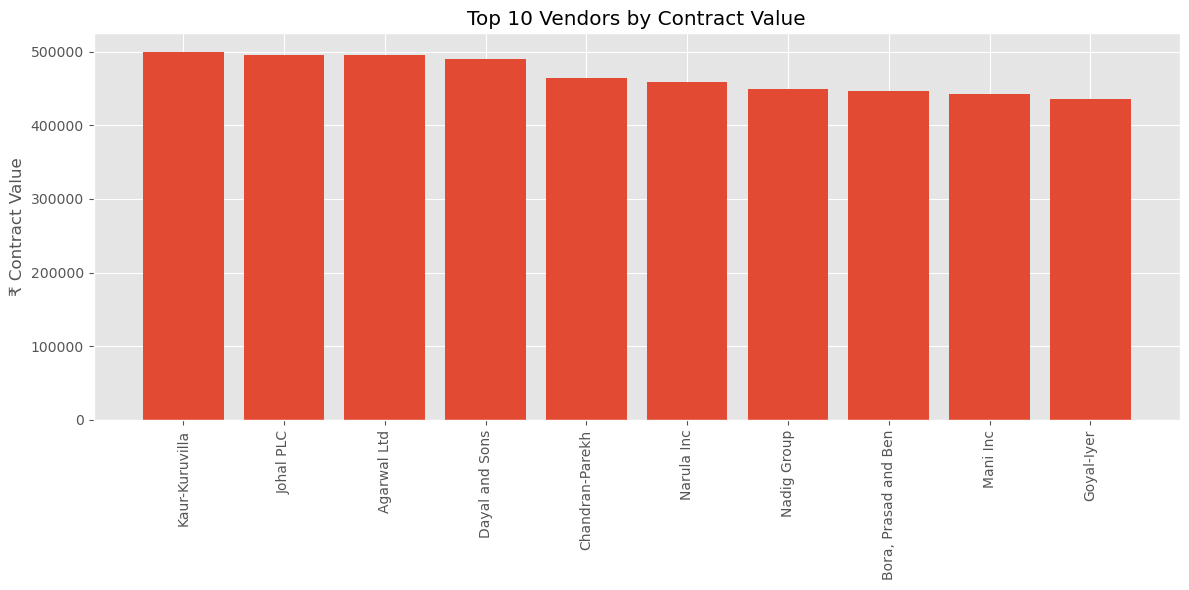

In [11]:
top = vendor_df.sort_values(
    "Contract_Value",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top["Vendor_Name"], top["Contract_Value"])

plt.xticks(rotation=90)

plt.title("Top 10 Vendors by Contract Value")

plt.ylabel("₹ Contract Value")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Top_Vendors.png"))

plt.show()

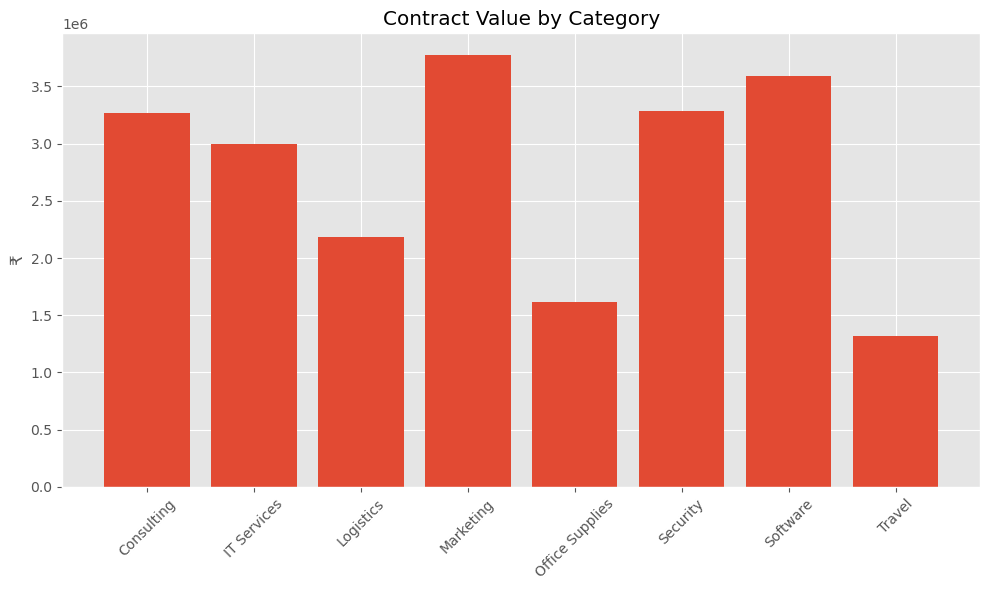

In [12]:
contract = vendor_df.groupby("Category")["Contract_Value"].sum()

plt.figure(figsize=(10,6))

plt.bar(contract.index, contract.values)

plt.xticks(rotation=45)

plt.title("Contract Value by Category")

plt.ylabel("₹")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Category_Contract_Value.png"))

plt.show()

In [13]:
vendor_df.sort_values(
    "Contract_Value",
    ascending=False
)[
    ["Vendor_Name",
     "Category",
     "Contract_Value"]
].head(10)

,Vendor_Name,Category,Contract_Value
8,Kaur-Kuruvilla,Security,499816.27
60,Johal PLC,Security,495748.62
74,Agarwal Ltd,Consulting,494909.79
69,Dayal and Sons,Logistics,489820.81
59,Chandran-Parekh,Marketing,464420.53
4,Narula Inc,IT Services,458950.28
77,Nadig Group,Security,448762.44
45,"Bora, Prasad and Ben",Marketing,446190.73
21,Mani Inc,Consulting,442537.86
17,Goyal-Iyer,Software,435774.24


In [14]:
summary = pd.DataFrame({

    "Metric":[

        "Total Vendors",
        "Paid",
        "Pending",
        "Partially Paid",
        "Total Contract Value",
        "Average Contract Value"

    ],

    "Value":[

        total_vendors,
        paid,
        pending,
        partial,
        total_contract,
        average_contract

    ]

})

summary.to_excel(

    os.path.join(

        reports_folder,

        "Vendor_Summary.xlsx"

    ),

    index=False

)

print("Vendor Summary Saved Successfully")

Vendor Summary Saved Successfully


In [15]:
print("="*60)

print("VENDOR DASHBOARD COMPLETED")

print("="*60)

print(f"Charts Saved  : {charts_folder}")

print(f"Reports Saved : {reports_folder}")

print("="*60)

VENDOR DASHBOARD COMPLETED
Charts Saved  : Executive_Assistant_Business_Dashboard\charts
Reports Saved : Executive_Assistant_Business_Dashboard\reports
